Here we will be understanding the role of
- Doppler shift: Change in frequency due to relative motion of Tx and Rx
- Doppler spread: Range of frequencies at rx observed due to multipath channel
- Dopper rate: change of velocity wrt time due to acceleration

- mmWave Range: 30 to 300GHz

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from BMOCZ import BMOCZTransmitter

In [260]:
K = 2
Q = 4
tx = BMOCZTransmitter(K)
R = tx.R

In [399]:
a = 5 # m / sec**2
v0 = 20 # m/ sec
B = 100e3 * 1
c = 3e8
fc = 6e6
t = np.arange(K+1) * 5e-1
v = v0 + a * t 
dist = v0 * t + 0.5 * a * t**2
wavelength = c / fc
fd_t = v / wavelength

In [400]:
fd_Cumulative = np.cumsum(fd_t)
phi_t = 2 * np.pi * ( fd_t )

In [401]:
# msg = np.random.randint(0, 2, K)
msg = [0, 1]
sig_tx = tx.coeffCon(msg)
sig_rx = sig_tx * np.exp(1j * phi_t)

In [402]:
print(f"Wavelength: {wavelength}")
print(f"initial velocity: {v0}, acceleration: {a}")
print(f"Inequality: {v0 + 2*a} should be <= {0.8*wavelength}")

Wavelength: 50.0
initial velocity: 20, acceleration: 5
Inequality: 30 should be <= 40.0


In [403]:
print(f"Velocity: {v}")
print(f"Distance Covered: {dist}")
print(t)
print(f"fd(t): {fd_t}")
print(f"Cumulative fd(t): {fd_Cumulative}")
print(f"Phi(t): {phi_t}")
print(sig_rx)

Velocity: [20.  22.5 25. ]
Distance Covered: [ 0.    10.625 22.5  ]
[0.  0.5 1. ]
fd(t): [0.4  0.45 0.5 ]
Cumulative fd(t): [0.4  0.85 1.35]
Phi(t): [2.51327412 2.82743339 3.14159265]
[ 0.80901699-5.87785252e-01j -0.67249851+2.18508012e-01j
 -1.        +1.22464680e-16j]


In [404]:
sig_power = np.mean(np.abs(sig_tx)**2)
sig_norm = sig_tx / np.sqrt(sig_power)

In [405]:
rootsRx = np.roots(sig_rx[::-1])
rootsTx = np.roots(sig_tx[::-1])
print(f"Transmitted Roots: {rootsTx}")
print(f"Received Roots: {rootsRx}")

Transmitted Roots: [-1.41421356+1.73191211e-16j  0.70710678+7.70371978e-33j]
Received Roots: [-1.34499702+0.43701602j  0.67249851-0.21850801j]


In [406]:
for xr in rootsRx:
    for xt in rootsTx:
        if abs(xr) - abs(xt) <= 1e-15:
            print(f"Angle rotated: {np.angle(xr - xt)}") 

Angle rotated: 1.4137166941154065
Angle rotated: -0.10433378889450455
Angle rotated: -1.7278759594743858


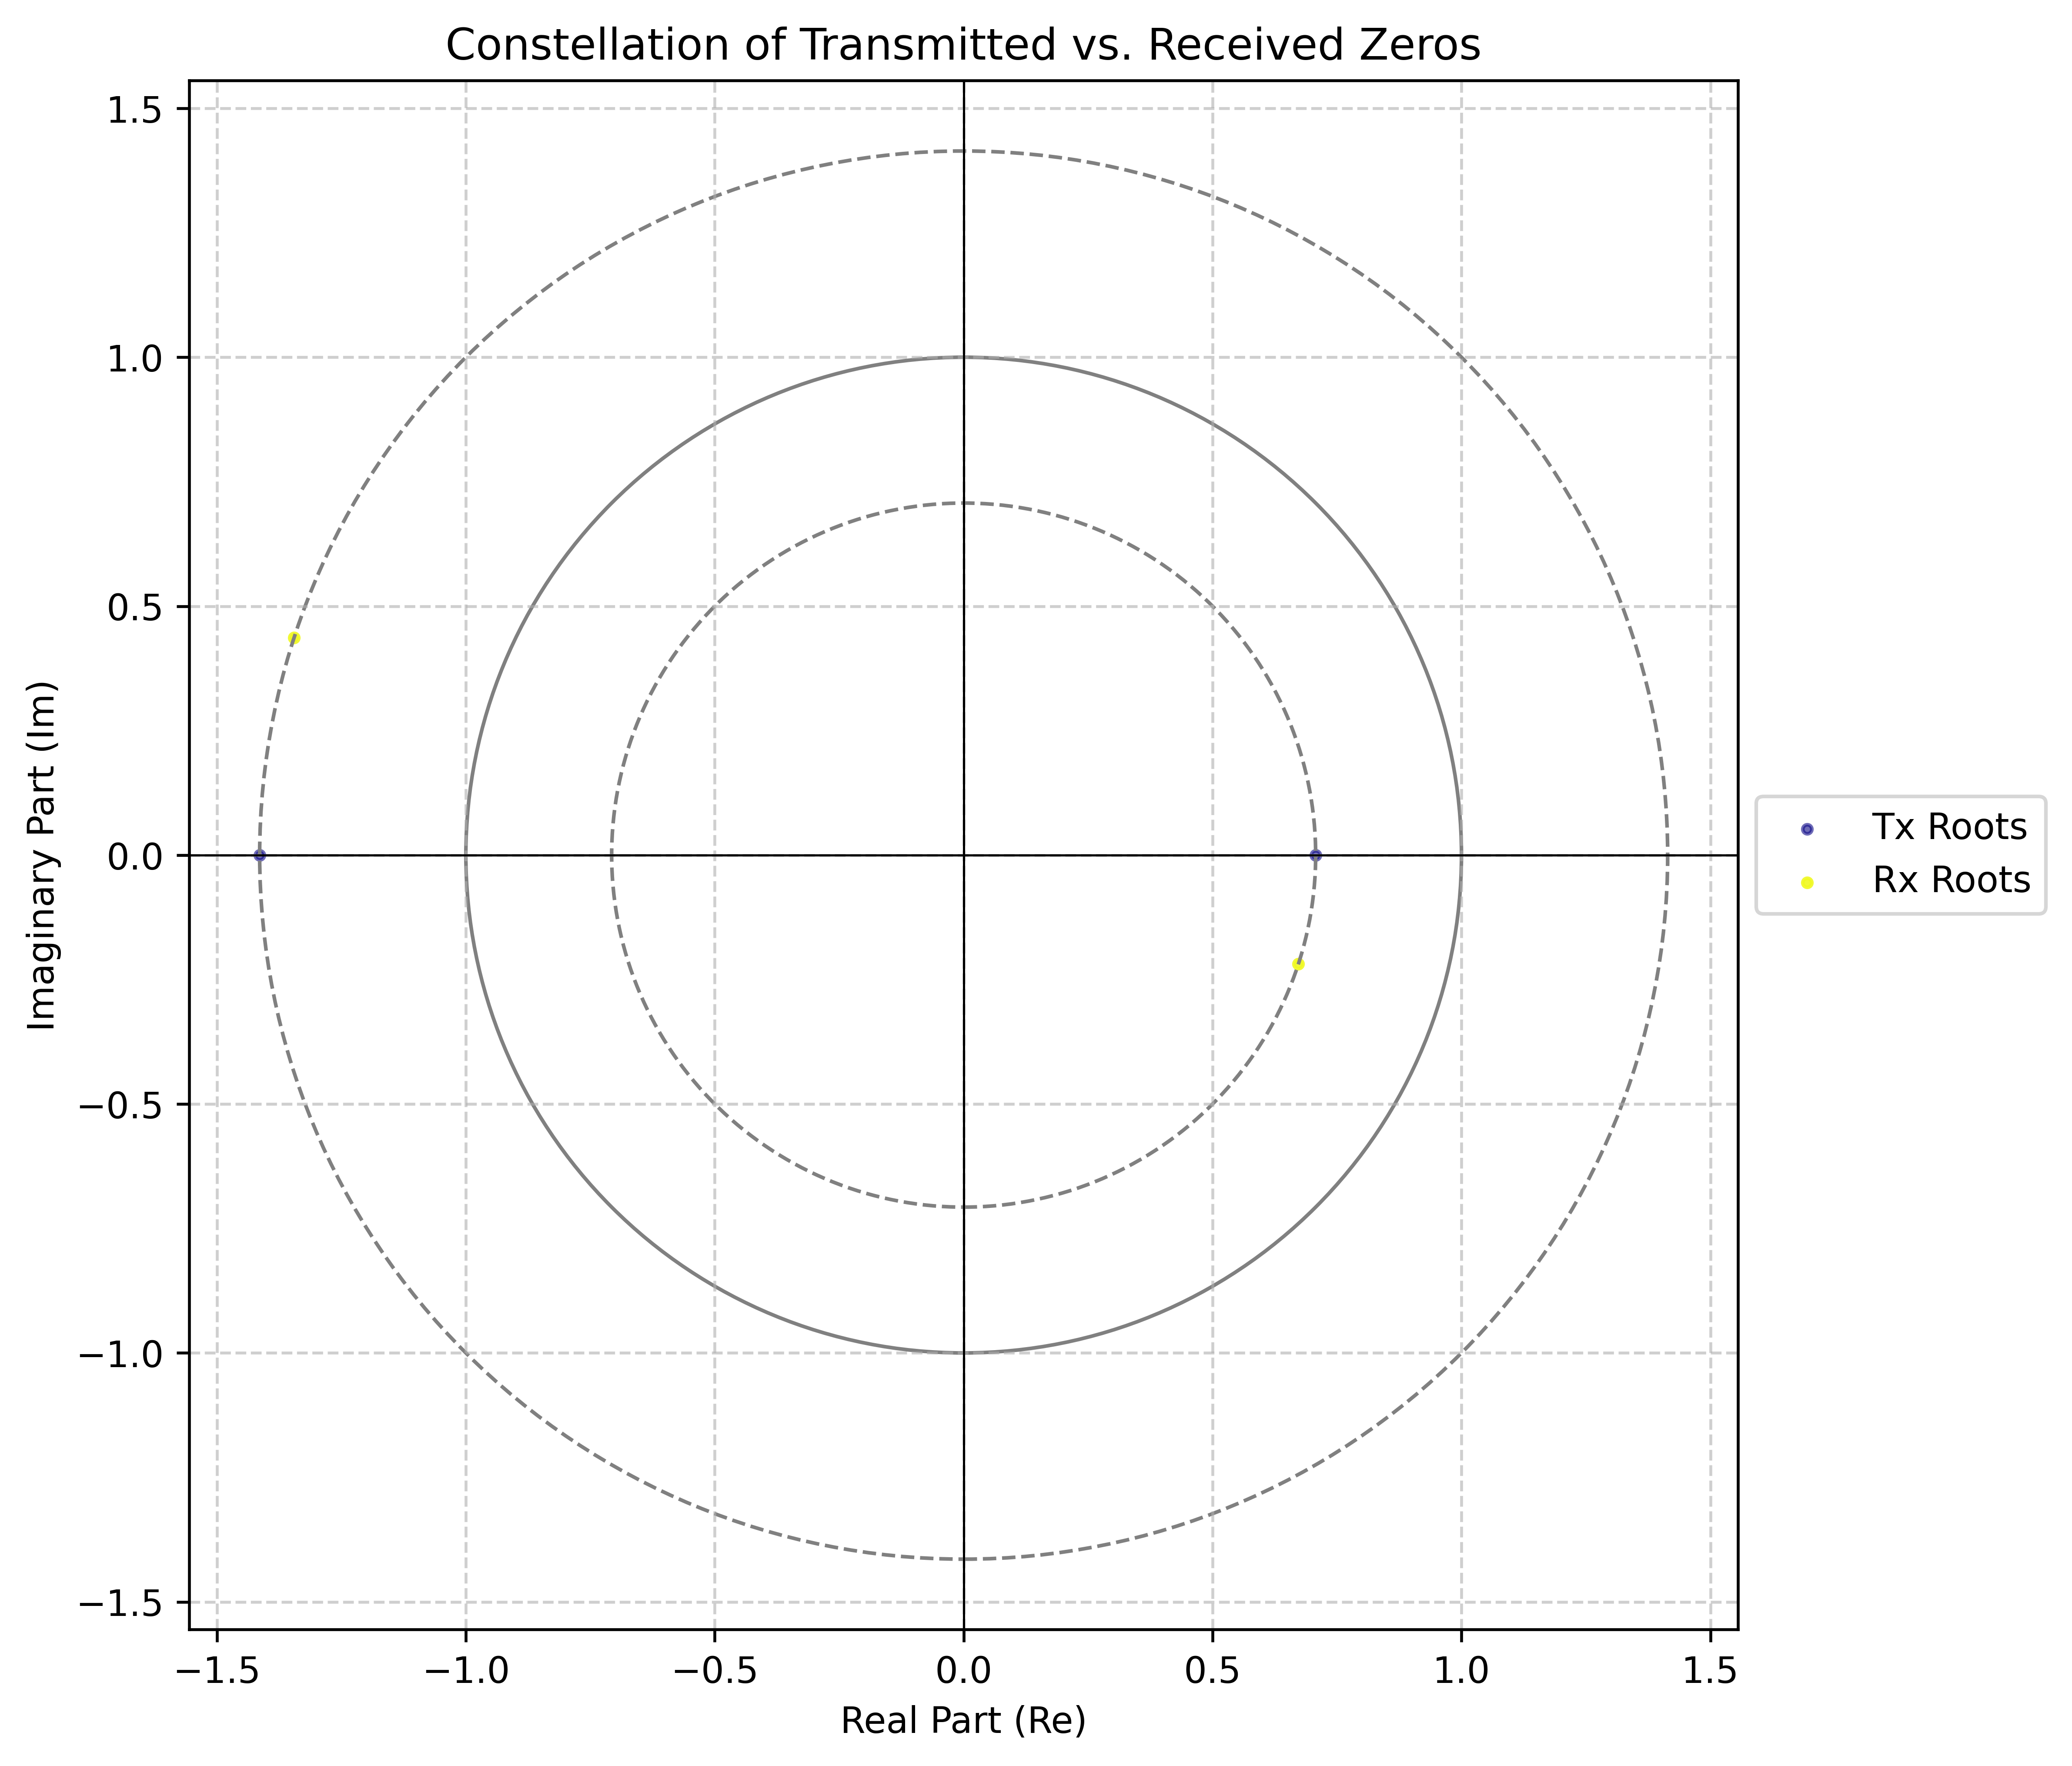

In [407]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=600) #

# Generate a list of distinct colors for the SNRs using a colormap
# 'plasma', 'viridis', or 'jet' work well for this
colors = plt.cm.plasma(np.linspace(0, 1, K))


ax.scatter(rootsTx.real, rootsTx.imag, color=colors[0], marker='.', s=25, alpha=0.6, label=f'Tx Roots')
ax.scatter(rootsRx.real, rootsRx.imag, color=colors[1], marker='.', s=25, alpha=0.9, label=f'Rx Roots')

# zorder=5 forces these points to be drawn on TOP of the scatter plot
# ax.plot(tx_zeros.real, tx_zeros.imag, marker='s', markerfacecolor='hotpink',
#         markeredgecolor='hotpink', linestyle='none', markersize=3, 
#         label='Tx Zeros', zorder=5)


circle1 = plt.Circle((0,0), radius=1, color='gray', fill=False, linestyle='-')
circle2 = plt.Circle((0,0), radius=1/R, color='gray', fill=False, linestyle='--')
circle3 = plt.Circle((0,0), radius=R, color='gray', fill=False, linestyle='--')

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

ax.set_aspect('equal', adjustable='box')

ax.axhline(0, color='black', linewidth=.6)
ax.axvline(0, color='black', linewidth=.6)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel('Real Part (Re)')
ax.set_ylabel('Imaginary Part (Im)')
ax.set_title('Constellation of Transmitted vs. Received Zeros')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Method-1: Using the transmitted BMOCZ symbol estimate the velocity and acceleration

- using the leading coefficient x(K)

- using x(K) and x(0) as there is a relation between both of them after signal normalization

In [256]:
K = 10
tx1 = BMOCZTransmitter(K)

fc = 30e9
c = 3e8
bw = 100e3
v0 = 50
a = 0
wavelength = c / fc
t = np.arange(K+1) / bw
v_t = v0 + a * t
fd_t = v_t / wavelength
fd_Cumulative = np.cumsum(fd_t)
phi_t = 2 * np.pi * fd_Cumulative

In [257]:
print(t)
print(f"phi(t): {phi_t}")

[0.e+00 1.e-05 2.e-05 3.e-05 4.e-05 5.e-05 6.e-05 7.e-05 8.e-05 9.e-05
 1.e-04]
phi(t): [ 31415.9265359   62831.8530718   94247.77960769 125663.70614359
 157079.63267949 188495.55921539 219911.48575129 251327.41228718
 282743.33882308 314159.26535898 345575.19189488]


In [258]:
msg = np.random.randint(0, 2, K)
sig_tx = tx1.coeffCon(msg)
sig_power = np.mean( np.abs(sig_tx)**2 )
sig_norm = sig_tx / sig_power

sig_rx = sig_norm * np.exp( 1j * phi_t )

In [259]:
normFactor = wavelength / (2 * np.pi)

xK = normFactor * np.angle(sig_rx[-1])
print(f"Angle of leading coefficient: {xK}")

x0 = (np.angle(sig_rx[0]) - np.pi) * normFactor
print(f"Velocity Estimated: {x0}")
print(f"Wavelength: {wavelength}")
print(sig_rx[0], sig_tx[0])
print(np.angle(sig_rx[0]), np.angle(sig_rx[0])-np.pi)
print(msg)

Angle of leading coefficient: -3.166295461500952e-14
Velocity Estimated: -7.746417624186699e-16
Wavelength: 0.01
(-2.6805236950900424+1.304838537545233e-12j) (-1.309016994374947+1.4432899320127035e-15j)
3.1415926535893064 -4.867217739956686e-13
[0 1 1 1 1 0 1 1 0 0]


- MOCZ for RADAR we will be considering multicarrier signal like OFDM instead of Traditional MOCZ

- We will be considering OFDM because using the Cyclic Prefix wecan estimate the accelerationa and velocity of the target

- Polynomial coefficients are mapped to the subcarriers and using IFFT they areconverted to time domain and transmitted

In [190]:
K = 7
Q = 4
tx = BMOCZTransmitter(K)
chLen = 4

In [201]:
a = 3
v0 = 5
fc = 30e9
c = 3e8
wavelength = c / fc
t = np.arange(K+1+chLen) 
v_t = v0 + a * t
fd_t = v_t / wavelength
fd_Cumulative = np.cumsum(fd_t)
phi_t = 2 * np.pi * fd_Cumulative

In [202]:
print(f"Wavelength: {wavelength}")
print(t)
print(f"phi(t): {phi_t}")

Wavelength: 0.01
[ 0  1  2  3  4  5  6  7  8  9 10 11]
phi(t): [  3141.59265359   8168.14089933  15079.64473723  23876.10416728
  34557.51918949  47123.88980385  61575.21601036  77911.49780903
  96132.73519985 116238.92818282 138230.07675795 162106.18092523]


In [207]:
msg = np.random.randint(0, 2, K)
sig_tx = tx.coeffCon(msg)
ofdmSym = np.append(sig_tx[-chLen:], sig_tx)
sig_rx = ofdmSym * np.exp(1j*phi_t)
#  --- received symbol
cyclicPrefix = sig_rx[:chLen]
rxSym = sig_rx[chLen:]

In [ ]:
for i in range(chLen):
    print(i)

0
1
2
3
